<a href="https://colab.research.google.com/github/aabaniel/ZeekData24-AI-Training/blob/main/CTTHES3_Models/ML_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Training Section

Support Vector Machine, Gradient Boosted Trees, and Random Forest

 1. **Split** the dataset for testing and validation into folds.
 1. **Select** a machine learning algorithm to be tested with the dataset by importing a specific machine learning algorithm in scikit-learn library.
 1. **Train** using the training folds and will be tested and evaluated using the validation folds wherein the researchers will also observe its accuracy, detection rate, recall, precision, false positive rate and take the average of it.
 1. **Evaluate** the combinations of the hyperparameters to maximize the performance of the model.          
 *If the best combination is found, then it will proceed to the next step. If not, then it will undergo hyperparameter tuning to find the best combination of the hyperparameters and will undergo training with the tuned hyperparameters.*
 1. The model will then be compared with the performance of other models to determine the best based on the given evaluation metrics.
 1. The best performing model will be then tested using the testing set that is still unseen by the model.

**Input** -===- Preprocessed Dataset

**Output** -==- Model & Scaler Output

In [11]:
# @title
!nvidia-smi

Fri Jun 12 18:43:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             28W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
# @title
%load_ext cuml.accel


The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [13]:
# @title
%pip install pandas numpy matplotlib scikit-learn imbalanced-learn

In [14]:
# @title
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, confusion_matrix

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/My Drive/zeek24data"

Mounted at /content/drive
 before				   check_onehot_ports.csv
 Benign,Ca,Discovery,RD		   check_remove_irrelevant.csv
 check_binning_of_continuous.csv   final_train.csv
 check_binning_of_ports.csv	  'final_train(no upsample).csv'
 check_boolean_encoding.csv	   infogain_MC.csv
 check_data_cleaning.csv	   test.csv
 check_drop_original.csv	  'test(no upsample).csv'
 check_drop_zero_infogain.csv	   train.csv
 check_keep_reconnaissance.csv	  'train(no upsample).csv'
 check_onehot_categorical.csv	   zeekdata_combined.csv
 check_onehot_continuous.csv	   zeekdatasets


In [15]:
# @title
from sklearn.metrics import make_scorer, confusion_matrix

def multiclass_weighted_fpr(y_true, y_pred):
    """Calculates the weighted False Positive Rate for multiclass classification."""
    cm = confusion_matrix(y_true, y_pred)

    # FP: Column sum - TP (diagonal)
    fp = cm.sum(axis=0) - np.diag(cm)
    # FN: Row sum - TP (diagonal)
    fn = cm.sum(axis=1) - np.diag(cm)
    # TP: Diagonal
    tp = np.diag(cm)
    # TN: Total - (FP + FN + TP)
    tn = cm.sum() - (fp + fn + tp)

    # FPR = FP / (FP + TN)
    fpr = fp / (fp + tn)

    # Handle potential division by zero
    fpr = np.nan_to_num(fpr)

    # Return weighted average based on class support (row sums)
    weights = cm.sum(axis=1)
    return np.average(fpr, weights=weights)

# Create the scorer object
fpr_scorer = make_scorer(multiclass_weighted_fpr)

In [16]:
##### FOR COLAB #####
train = "/content/drive/MyDrive/zeek24data/final_train.csv"
test = "/content/drive/MyDrive/zeek24data/test.csv"
'''
train = "/content/train_binary.csv"
test = "/content/test_binary.csv"

train = "../datasets/final_train.csv"
test = "../datasets/test.csv"
'''

df = pd.read_csv(train)
test_df = pd.read_csv(test)

df.head()



,Unnamed: 0,local_resp,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,...,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown,label_tactic
0,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
1,1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
2,2,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
3,3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
4,4,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access


In [21]:
df = df.drop(df.columns[0], axis=1)
test_df = test_df.drop(test_df.columns[0], axis=1)
df.head()

,local_resp,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown,label_tactic
0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
2,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access
4,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0,0,0,0,0,0,1,0,Credential Access


In [23]:
X_train = df.drop(columns=["label_tactic"])
y_train = df["label_tactic"]

X_test = test_df.drop(columns=["label_tactic"])
y_test = test_df["label_tactic"]
X_train.head()

,local_resp,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSADdR,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown
0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,1,0
1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,1,0
2,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0,0,0,0,0,0,1,0
3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0,0,0,0,0,0,1,0
4,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0,0,0,0,0,0,1,0


In [18]:
'''
X_train = df.drop(columns=["label_binary_class"])
y_train = df["label_binary_class"]

X_test = test_df.drop(columns=["label_binary_class"])
y_test = test_df["label_binary_class"]
'''

'\nX_train = df.drop(columns=["label_binary_class"])\ny_train = df["label_binary_class"]\n\nX_test = test_df.drop(columns=["label_binary_class"])\ny_test = test_df["label_binary_class"]\n'

In [24]:
# @title
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# @title
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C= 0.1,
    loss = 'squared_hinge',
    max_iter=1000,
    tol=1e-4,
    dual=True
)

scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    svm,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],
    "test_fpr": cv_results["test_fpr_weighted"],
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, min={vals.min():.4f}, max={vals.max():.4f}")

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")

param_grid = [
    {
        'loss': ['hinge'],
        'dual': [True],
        'C': [0.01, 0.1, 1, 10, 100],
        'tol': [1e-4, 1e-3, 1e-2],
        'max_iter': [1000, 5000, 10000],
    },
    {
        'loss': ['squared_hinge'],
        'dual': [True, False],
        'C': [0.01, 0.1, 1, 10, 100],
        'tol': [1e-4, 1e-3, 1e-2],
        'max_iter': [1000, 5000, 10000],
    }
]

grid_search = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


10-Fold Cross-Validation (Fold-by-Fold):
 fold  train_accuracy  test_accuracy  train_precision_weighted  test_precision_weighted  train_recall_weighted  test_recall_weighted  train_f1_weighted  test_f1_weighted  fit_time_sec  score_time_sec  train_fpr  test_fpr
    1          0.9308         0.9305                    0.9257                   0.9253                 0.9308                0.9305             0.9216            0.9211        1.5969          0.6971     0.0338    0.0340
    2          0.9306         0.9320                    0.9254                   0.9277                 0.9306                0.9320             0.9214            0.9222        1.8169          0.6986     0.0338    0.0338
    3          0.9310         0.9287                    0.9260                   0.9225                 0.9310                0.9287             0.9218            0.9190        1.1213          0.3803     0.0337    0.0345
    4          0.9305         0.9325                    0.9254             

In [26]:
# @title
from sklearn.metrics import cohen_kappa_score, precision_recall_curve, auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from scipy.special import softmax

svm = grid_search.best_estimator_
y_pred = svm.predict(X_test_scaled)
# LinearSVC doesn't have predict_proba, so use decision_function and convert to probabilities
y_pred_proba = svm.decision_function(X_test_scaled)
# Normalize to [0, 1] range using softmax-like transformation
y_pred_proba = softmax(y_pred_proba, axis=1)

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

classes = sorted(np.unique(y_test))
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

print("\nPer-Class Metrics:")
print(f"{'Class':<25} {'PR-AUC':<12} {'ROC-AUC':<12}")
print("-" * 50)

pr_auc_scores = []
roc_auc_scores = []

for i, cls in enumerate(classes):
    try:
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
        pr_auc = auc(recall, precision)
        pr_auc_scores.append(pr_auc)

        roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc_scores.append(roc_auc)

        print(f"{cls:<25} {pr_auc:<12.4f} {roc_auc:<12.4f}")
    except Exception as e:
        print(f"{cls:<25} Error: {str(e)}")

print("-" * 50)
print(f"{'Macro Average':<25} {np.mean(pr_auc_scores):<12.4f} {np.mean(roc_auc_scores):<12.4f}")
print(f"{'Weighted Average':<25} {np.average(pr_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f} {np.average(roc_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f}")

print(classification_report(y_test, y_pred))

Cohen's Kappa Score: 0.8460

Per-Class Metrics:
Class                     PR-AUC       ROC-AUC     
--------------------------------------------------
Credential Access         1.0000       1.0000      
Discovery                 0.9602       0.9895      
Reconnaissance            0.4008       0.8768      
none                      0.9889       0.9899      
--------------------------------------------------
Macro Average             0.8375       0.9640      
Weighted Average          0.9601       0.9870      
                   precision    recall  f1-score   support

Credential Access       1.00      1.00      1.00      8699
        Discovery       0.98      0.78      0.87     13430
   Reconnaissance       0.24      0.70      0.36      2037
             none       0.99      0.94      0.96     27403

         accuracy                           0.90     51569
        macro avg       0.80      0.86      0.80     51569
     weighted avg       0.96      0.90      0.92     51569



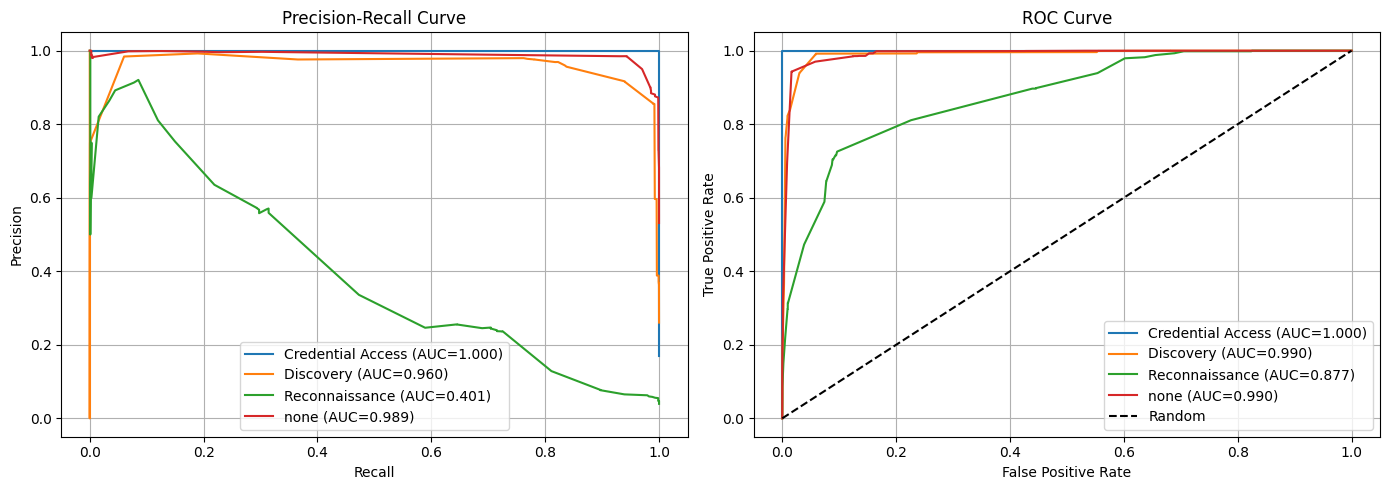

In [27]:
# @title
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_pred_scores = grid_search.best_estimator_.decision_function(X_test_scaled)
y_pred_proba = softmax(y_pred_scores, axis=1)
classes = sorted(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# subplots for PR and ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot PR
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc = auc(recall, precision)
    axes[0].plot(recall, precision, label=f'{cls} (AUC={pr_auc:.3f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='best')
axes[0].grid(True)

# plot ROC
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='best')
axes[1].grid(True)

plt.tight_layout()
plt.show()


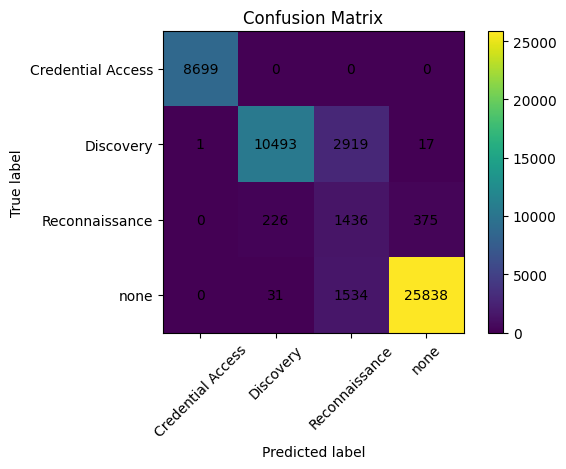

In [28]:
from sklearn.metrics import confusion_matrix

y_pred = grid_search.best_estimator_.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.clim(0, cm.max())
class_names = sorted(np.unique(y_test))
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()